In [2]:
# Use this in Colab session
#%cd /content
#!rm -rf rainfall_kf
#
#!git clone https://github.com/Felix-Schwer/rainfall_kf.git
#%cd rainfall_kf

# Use this on local machine
%cd C:/Users/fschwer/Documents/CEE 261D Data Assimilation/Final Project/rainfall_kf

!pip install -e .

C:\Users\fschwer\Documents\CEE 261D Data Assimilation\Final Project\rainfall_kf
Obtaining file:///C:/Users/fschwer/Documents/CEE%20261D%20Data%20Assimilation/Final%20Project/rainfall_kf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for rainfall_kf (pyproject.toml): started
  Building editable for rainfall_kf (pyproject.toml): finished with status 'done'
  Created wheel for rainfall_kf: filename=rainfall_kf-0.1.0-0.editable-py3-none-any.whl size=2787 sha256=010c295969ca20a2ce8810d1b122dad555ef24e92f80a1d2df77f0a57e00f71b
  St

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# have to cd on local machine
%cd C:/Users/fschwer/Documents/CEE 261D Data Assimilation/Final Project/rainfall_kf/notebooks

prism_ds = xr.open_dataset('../data/prism_basin_means.nc')
gpm_ds = xr.open_dataset('../data/gpm_basin_means.nc')
et_ds = xr.open_dataset('../data/et_basin_means.nc')
temp_ds = xr.open_dataset('../data/temp_basin_means.nc')

from rainfall_kf.models.hbvedu import processed_inputs_fromds
et_ds, (monthly_et, monthly_temp) = processed_inputs_fromds(et_ds, temp_ds, starttime='2000-01-01', endtime='2020-12-31')


C:\Users\fschwer\Documents\CEE 261D Data Assimilation\Final Project\rainfall_kf\notebooks


In [2]:
stations_in_basin = {
    "18040001": ["11273400"], # Middle San Joaquin-Lower Chowchilla
    "18040002": ["11274550"], # Lower San Joaquin River
    "18040003": ["11303500"], # San Joaquin Delta
    "18040006": [], # Upper San Joaquin
    "18040007": [], # Fresno River
    "18040008": ["11272500"],# Upper Merced
    "18040009": ["11290000"], # Upper Tuolumne
    "18040010": ["11303000"], # Upper Stanislaus
    "18040011": [], # Upper Calaveras
    "18040012": ["11325500"], # Upper Mokelumne
    "18040013": [], # Upper Cosumnes
    "18040014": ["11255575"] # Panoche-San Luis Reservoir
}

stream_ds = xr.open_dataset('../data/streamflow.nc')

In [3]:
from rainfall_kf.models.hbv2 import SJV_Sierra_UBParameters, SJV_Sierra_LBParameters, SJV_Valley_UBParameters, SJV_Valley_LBParameters
Params = 0.2 * SJV_Valley_UBParameters + (1 - 0.2) * SJV_Valley_LBParameters

In [4]:
basin_id = "18040009"
station_id = stations_in_basin[basin_id][0]
start_time = stream_ds.sel(site=station_id).continuous_start.values
end_time = stream_ds.sel(site=station_id).continuous_end.values

In [5]:
inputs = np.array([
    temp_ds.tmean.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    gpm_ds.precipitation.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_temp.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_et.sel(basin=basin_id, time=slice(start_time, end_time)).values
])

times = stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time)).time.values
observations_imperial = stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time))
cfs_to_m3s = 0.0283168
sqmi_to_km2 = 2.58999
basin_area_km2 = stream_ds.sel(site=station_id).drainage_area.values * sqmi_to_km2
observations_da = observations_imperial * cfs_to_m3s / basin_area_km2 # m3/s/km2
observations_da = observations_da * 86400 / 1000000 * 1000 # m/day
observations = np.array([observations_da.values])

In [6]:
from rainfall_kf.enkf import EnsembleKalmanFilter
from rainfall_kf.models.hbvedu import HBVTransition, HBVObservation
from rainfall_kf.models.hbv2 import RainfallCorrTransition, RainfallCorrObservation

N_STATES = 6
N_OBS = 1
N_ENS = 100

gpm = gpm_ds.precipitation.sel(basin=basin_id, time=slice(start_time + pd.Timedelta(days=366), end_time))
prism = prism_ds.precipitation.sel(basin=basin_id, time=slice(start_time + pd.Timedelta(days=366), end_time))
#-------------------------------------------------------------------
correction = 'multiplicative' # 'additive', 'multiplicative', or 'logmul'
method = 'random_walk' # 'random_walk' or 'autoregressive'
storm_threshold = 5 # mm/day
#-------------------------------------------------------------------
SIGB = {'additive': 5, 'multiplicative': 0.5, 'logmul': 0.02}
Qassumed = np.diag([2, 2, 0.5, 0.5, 1e-40, SIGB[correction]])**2
Rassumed = np.diag([0.5])**2

x0 = np.array([[0., 100., 10., 10., 10., 0.]]).T # initial state guess
initial_ensemble = x0 + np.linalg.cholesky(Qassumed).T @ np.random.randn(N_STATES, N_ENS)

THRESH = None if storm_threshold == 0 else storm_threshold
TransitionEquation = lambda states, inputs: RainfallCorrTransition(states, inputs, Params, correction=correction, method=method, storm_threshold=THRESH, phi=0.8)

enkf = EnsembleKalmanFilter(
    TransitionEquation=TransitionEquation,
    ObservationEquation=lambda states: HBVObservation(states, Params),
    Q=Qassumed,
    R=Rassumed,
    addGaussInputSig=np.array([0.2, 0., 0., 0.]),
    mulLognormInputSig=np.array([0., 0.2, 0., 0.]),
    gain_method='pinv', #pinv or analytic
)

result = enkf.run(initial_ensemble=initial_ensemble, times=times, inputs=inputs, observations=observations)
b = xr.DataArray(result.ensembles[:, 5, :].mean(axis=1), coords=[times], dims=['time']).sel(time=slice(start_time + pd.Timedelta(days=366), end_time))
if correction == 'additive':
    corrected = gpm + b.where(gpm >= storm_threshold, 0)
elif correction == 'multiplicative':
    corrected = gpm * (1 + b.where(gpm >= storm_threshold, 0))
elif correction == 'logmul':
    corrected = gpm * np.exp(b.where(gpm >= storm_threshold, 0))
pred_obs = xr.DataArray(result.predicted_observations[0], coords=[result.times], dims=['time'])

In [9]:
k_ds = xr.Dataset({'gain': (('time','state','obs'), result.k),},
                    coords={'time': result.times, 'state': ['snow', 'soil', 's1', 's2', 's1_prev', 'b'], 'obs': ['q']})
mag_ds = xr.Dataset({'mag': (('time','state'),
                             np.abs(result.ensembles).mean(axis=2))}, coords={'time': result.times, 'state': ['snow', 'soil', 's1', 's2', 's1_prev', 'b']})

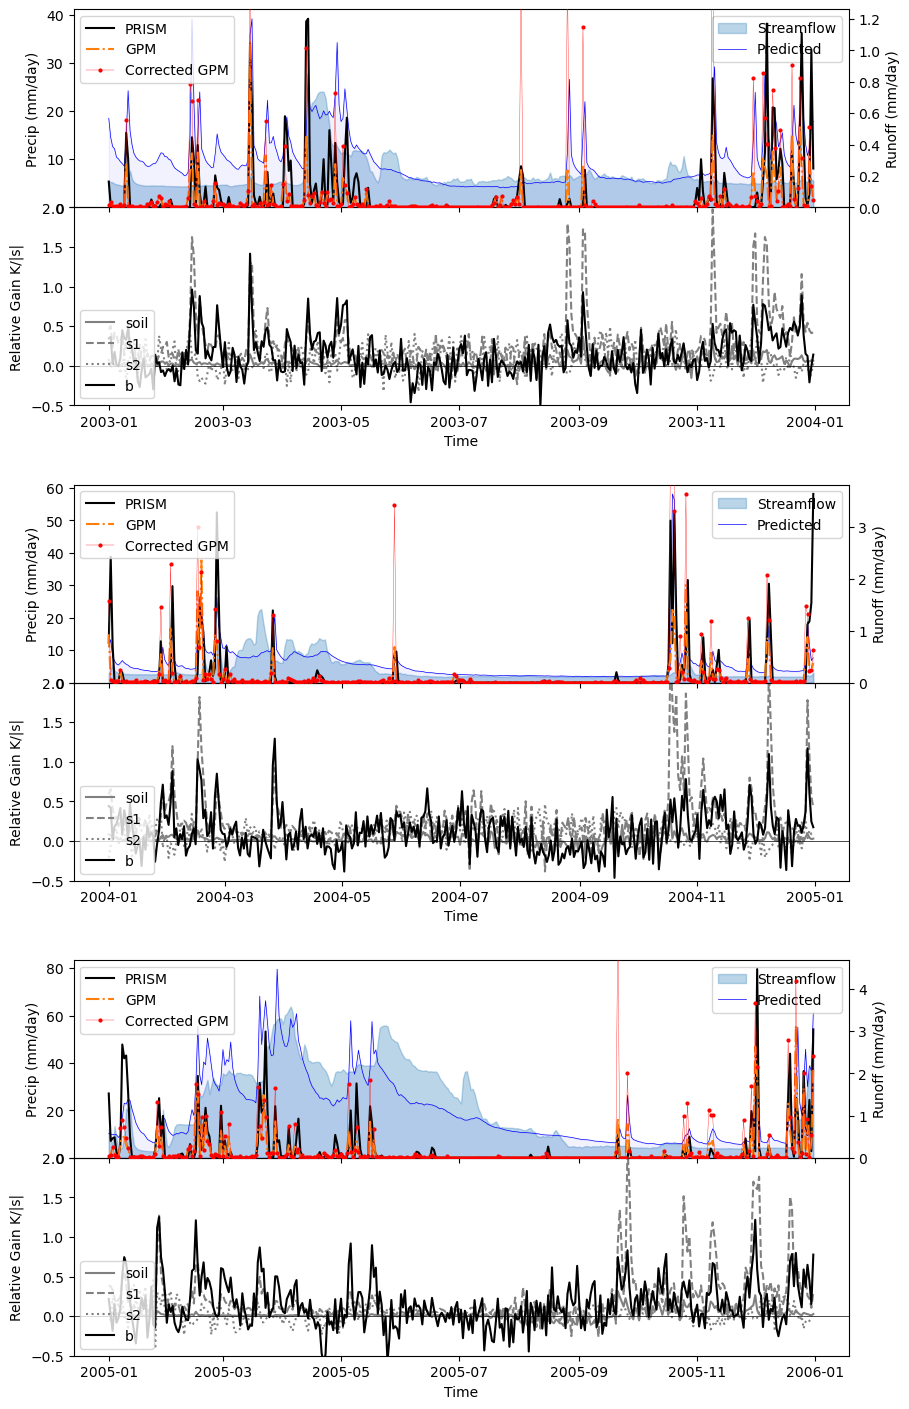

In [16]:
date_range = pd.date_range('2003-01-01', '2005-12-31', freq='D')
fig, axes = plt.subplots(2*(date_range.year.max()-date_range.year.min()+1), 1, figsize=(10, 2*3*(date_range.year.max()-date_range.year.min()+1)))
for i,year in enumerate(range(date_range.year.min(), date_range.year.max() + 1)):
    year_range = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')
    bx = axes[2*i].twinx()
    bx.fill_between(year_range, observations_da.sel(time=year_range), color='tab:blue', alpha=0.3, label='Streamflow')
    bx.plot(year_range, pred_obs.sel(time=year_range), color='blue', label='Predicted', lw=0.5)
    bx.fill_between(year_range, pred_obs.sel(time=year_range), color='blue', alpha=0.05,)

    axes[2*i].plot(year_range, prism_ds.precipitation.sel(basin=basin_id, time=year_range), label='PRISM', color='k')
    axes[2*i].plot(year_range, gpm_ds.precipitation.sel(basin=basin_id, time=year_range), label='GPM', color='tab:orange', ls='-.')
    ylims = axes[2*i].get_ylim()
    axes[2*i].plot(year_range, corrected.sel(time=year_range), label='Corrected GPM', color='red', lw=0.25, marker='o', markersize=2)

    axes[2*i].set_ylim(0,ylims[1])
    bx.set_ylim(bottom=0)
    axes[2*i].legend(loc='upper left')
    bx.legend(loc='upper right')
    axes[2*i].set_ylabel('Precip (mm/day)')
    bx.set_ylabel('Runoff (mm/day)')

    axes[2*i].set_zorder(axes[i].get_zorder()+1)
    axes[2*i].set_frame_on(False)

    axes[2*i+1].sharex(axes[2*i])
    pos = axes[2*i].get_position()
    axes[2*i+1].set_position([pos.x0, pos.y0 - pos.height, pos.width, pos.height])
    axes[2*i+1].set_xlabel('Time')
    axes[2*i+1].tick_params(labelbottom=True, labeltop=False, labelleft=True, labelright=False)
    axes[2*i].tick_params(labelbottom=False)

    axes[2*i+1].plot(year_range, k_ds.gain.sel(state='soil', obs='q', time=year_range)/mag_ds.mag.sel(state='soil', time=year_range),
                     label='soil', color='gray')
    axes[2*i+1].plot(year_range, k_ds.gain.sel(state='s1', obs='q', time=year_range)/mag_ds.mag.sel(state='s1', time=year_range),
                     label='s1', color='gray', ls='--')
    axes[2*i+1].plot(year_range, k_ds.gain.sel(state='s2', obs='q', time=year_range)/mag_ds.mag.sel(state='s2', time=year_range),
                     label='s2', color='gray', ls=':')
    axes[2*i+1].plot(year_range, k_ds.gain.sel(state='b', obs='q', time=year_range)/mag_ds.mag.sel(state='b', time=year_range),
                     label='b', color='k')
    axes[2*i+1].axhline(0, color='k', lw=0.5)
    axes[2*i+1].legend(loc='lower left')
    axes[2*i+1].set_ylim(-0.5,2)
    axes[2*i+1].set_ylabel('Relative Gain K/|s|')

fig.savefig('../presentation/uncalibrated_timeseries_tuolumne.png', dpi=300, bbox_inches='tight')

Text(0.5, 0, 'Lags')

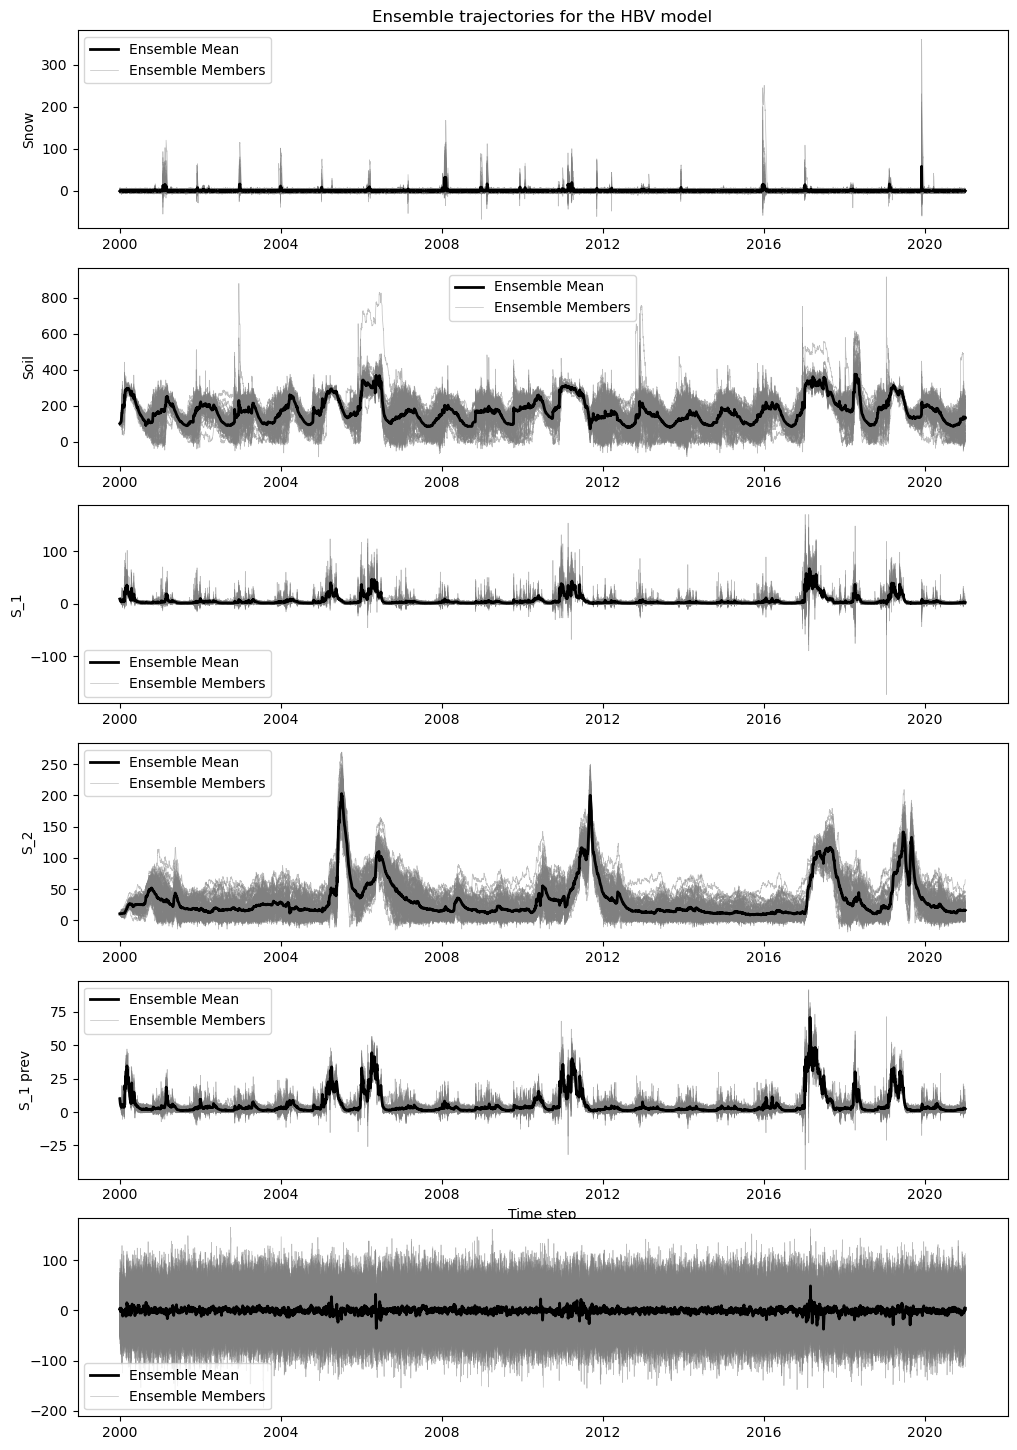

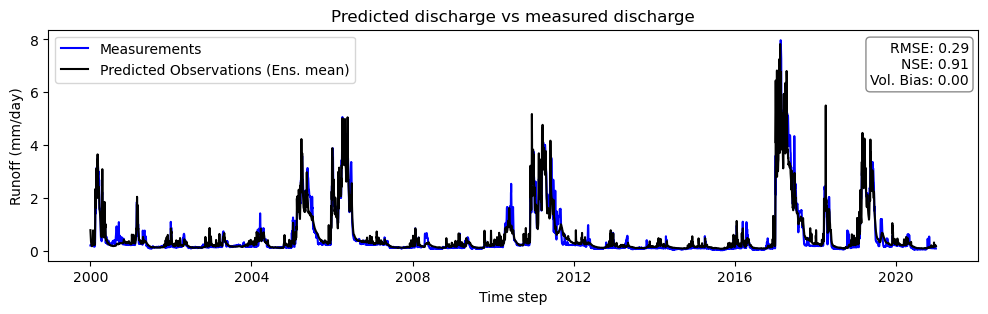

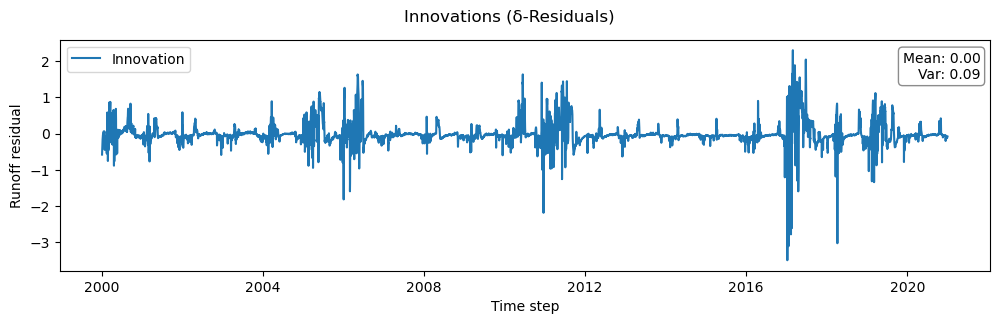

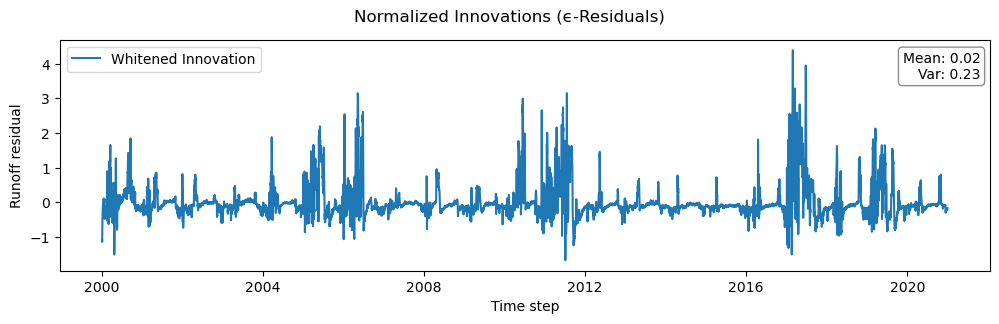

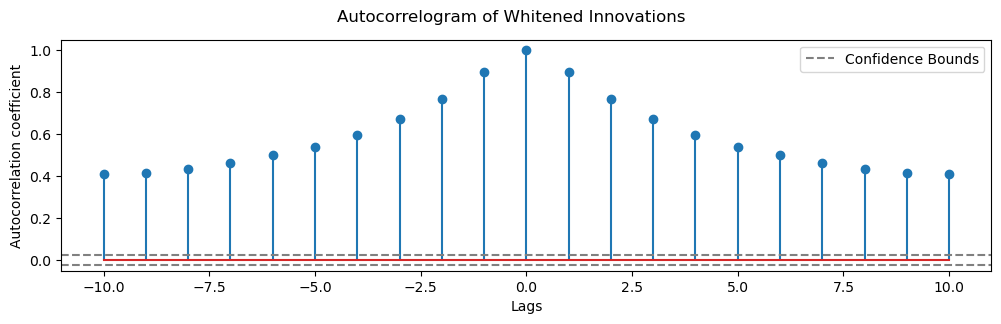

In [89]:
fig = result.plot_ensembles()
axes = fig.get_axes()
axes[0].set_title("Ensemble trajectories for the HBV model")
axes[0].set_ylabel("Snow")
axes[1].set_ylabel("Soil")
axes[2].set_ylabel("S_1")
axes[3].set_ylabel("S_2")
axes[4].set_ylabel("S_1 prev")
axes[4].set_xlabel("Time step")

fig = result.plot_observations()
ax = fig.get_axes()[0]
ax.set_title("Predicted discharge vs measured discharge")
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff (mm/day)")

fig = result.plot_innovations()
ax = fig.get_axes()[0]
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff residual")

fig = result.plot_whitened_innovations()
ax = fig.get_axes()[0]
ax.set_ylabel("Runoff residual")
ax.set_xlabel("Time step")

fig = result.plot_autocorrelogram()
ax = fig.get_axes()[0]
ax.set_ylabel("Autocorrelation coefficient")
ax.set_xlabel("Lags")

In [90]:
b = xr.DataArray(result.ensembles[:, 5, :].mean(axis=1), coords=[times], dims=['time'])

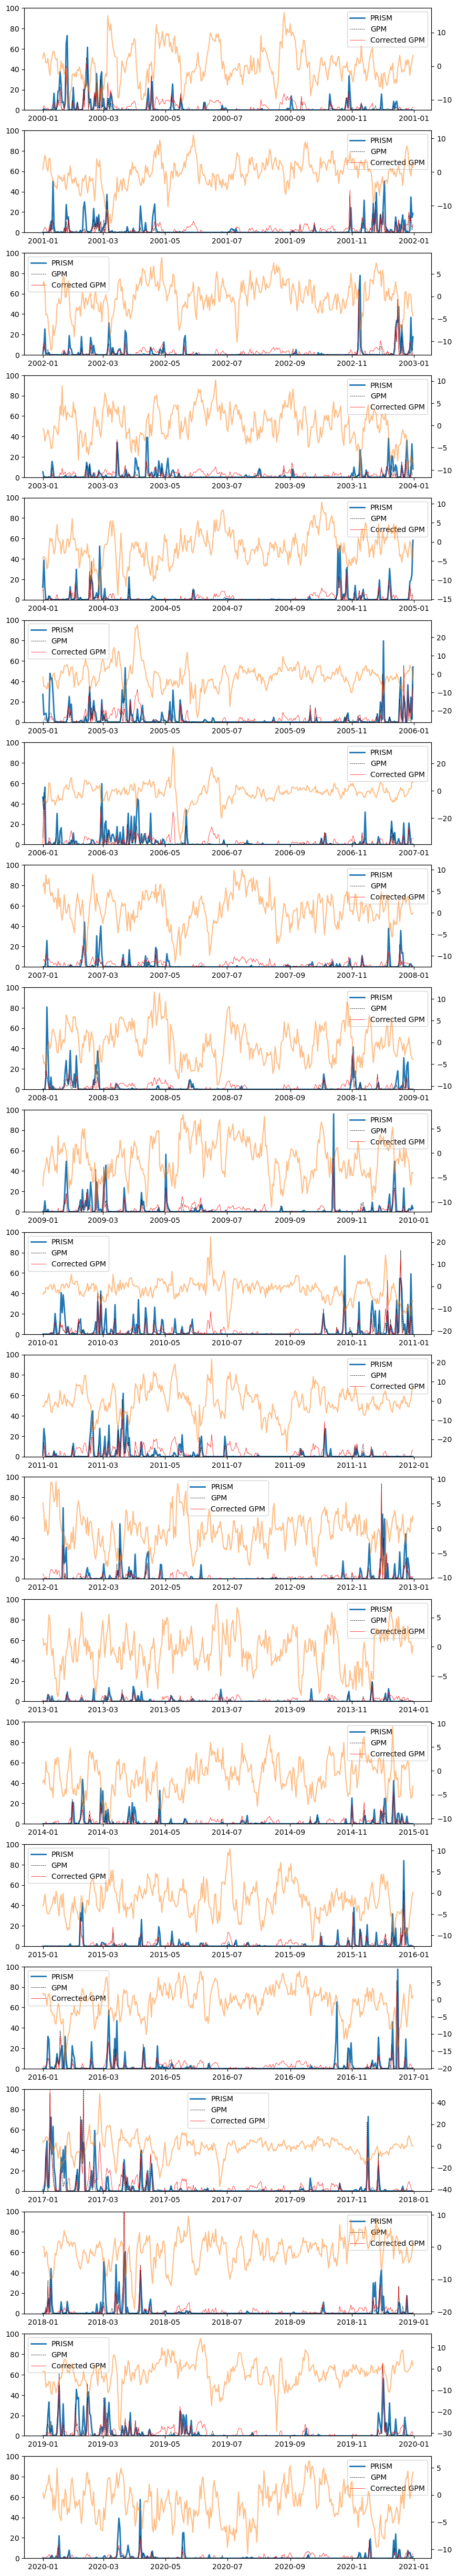